RANSAC Estimated Slope (m): -1.7305
Question 11 - Estimated Crop Field Angle (RANSAC): 59.98 degrees


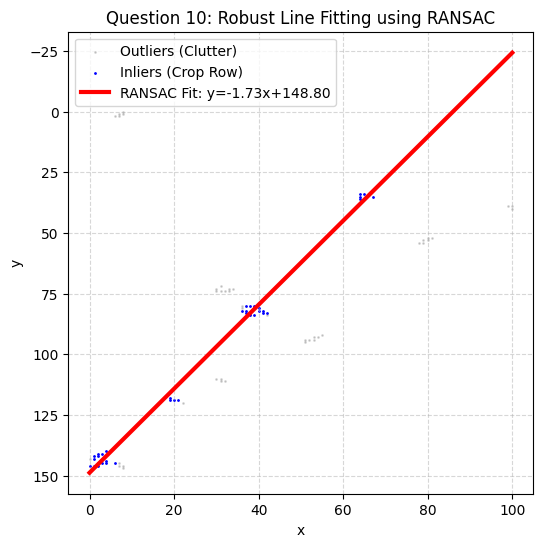

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Image and Extract Coordinates ---
filename = 'Cropped segment of the image.png'
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not find '{filename}'.")
else:
    edges = cv.Canny(img, 550, 690)
    indices = np.where(edges != 0)
    x = indices[1]
    y = indices[0]

    # --- 2. Proposed Algorithm: Custom RANSAC ---
    # Modified to return the indices of the inliers so we can color them!
    def custom_ransac_line_fit(x, y, iterations=2000, threshold=5.0):
        best_m = 0
        best_c = 0
        best_inlier_count = 0
        best_inliers_idx = []
        n_points = len(x)
        
        for _ in range(iterations):
            idx = np.random.choice(n_points, 2, replace=False)
            x1, y1 = x[idx[0]], y[idx[0]]
            x2, y2 = x[idx[1]], y[idx[1]]
            
            if x1 == x2: continue
                
            m = (y2 - y1) / (x2 - x1)
            c = y1 - m * x1
            
            distances = np.abs(m * x - y + c) / np.sqrt(m**2 + 1)
            inliers_idx = np.where(distances < threshold)[0]
            
            if len(inliers_idx) > best_inlier_count:
                best_inlier_count = len(inliers_idx)
                best_inliers_idx = inliers_idx
                
        if len(best_inliers_idx) > 0:
            inlier_x = x[best_inliers_idx]
            inlier_y = y[best_inliers_idx]
            best_m, best_c = np.polyfit(inlier_x, inlier_y, 1)
            
        return best_m, best_c, best_inliers_idx

    # Run the custom RANSAC algorithm
    m_robust, b_robust, inliers_idx = custom_ransac_line_fit(x, y, iterations=2000, threshold=3.0)
    
    # Calculate the angle of the line in degrees (for Question 11)
    angle_ransac = np.degrees(np.arctan(m_robust))

    # --- Print Outputs ---
    print(f"RANSAC Estimated Slope (m): {m_robust:.4f}")
    print(f"Question 11 - Estimated Crop Field Angle (RANSAC): {abs(angle_ransac):.2f} degrees")

    # --- 3. Plotting (Using your friend's Inlier/Outlier masking) ---
    # Create True/False masks to separate the points
    inlier_mask = np.zeros(len(x), dtype=bool)
    inlier_mask[inliers_idx] = True
    outlier_mask = ~inlier_mask # The '~' symbol means "NOT inlier"

    plt.figure(figsize=(6, 6))
    
    # Plot Outliers in Gray
    plt.scatter(x[outlier_mask], y[outlier_mask], s=1, c='gray', alpha=0.3, label='Outliers (Clutter)')
    
    # Plot Inliers in Blue
    plt.scatter(x[inlier_mask], y[inlier_mask], s=1, c='blue', label='Inliers (Crop Row)')

    # Draw the Red RANSAC line
    x_fit = np.array([np.min(x), np.max(x)])
    y_fit = m_robust * x_fit + b_robust
    plt.plot(x_fit, y_fit, color='red', linewidth=3, label=f'RANSAC Fit: y={m_robust:.2f}x+{b_robust:.2f}')

    plt.gca().invert_yaxis() # Invert Y-axis for image coordinates
    
    plt.title('Question 10: Robust Line Fitting using RANSAC')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    
    plt.show()